# Détection et traitement des anomalies

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

transactions = pd.read_csv('data/transactions.csv')
customers = pd.read_csv('data/customers.csv')

print(f"transactions.csv : {transactions.shape[0]:,} lignes × {transactions.shape[1]} colonnes")
print(f"customers.csv    : {customers.shape[0]:,} lignes × {customers.shape[1]} colonnes")

transactions.csv : 1,837,137 lignes × 8 colonnes
customers.csv    : 50,000 lignes × 9 colonnes


In [57]:
n_before = len(transactions)
n_null_cid = transactions['customer_id'].isna().sum()
print(f"Lignes sans customer_id : {n_null_cid:,} ({100*n_null_cid/n_before:.1f}%)")

# Suppression des lignes sans customer_id
transactions = transactions.dropna(subset=['customer_id'])
transactions['customer_id'] = transactions['customer_id'].astype(int)

print(f"Après suppression : {len(transactions):,} lignes (−{n_null_cid:,})")

Lignes sans customer_id : 418,258 (22.8%)
Après suppression : 1,418,879 lignes (−418,258)


418 258 lignes n'ont pas d'id client, environ 23%.
Ce sont sûrement des ventes anonymes en magasin.
Je supprime ces lignes car ça fausserait le RFM par client. 

In [58]:
n_before = len(transactions)

# Détail des quantités négatives
c_invoices = transactions[transactions['invoice_id'].str.startswith('C')]
neg_qty = transactions[transactions['quantity'] < 0]
neg_not_c = transactions[(transactions['quantity'] < 0) & (~transactions['invoice_id'].str.startswith('C'))]

print(f"Quantités ≤ 0 au total       : {(transactions['quantity'] <= 0).sum():,}")
print(f"  dont factures 'C' (annulations) : {len(c_invoices):,}")
print(f"  dont qty < 0 hors 'C'           : {len(neg_not_c):,}")
print(f"  dont qty NaN                     : {transactions['quantity'].isna().sum():,}")

# Suppression
transactions = transactions[transactions['quantity'] > 0]
print(f"\nAprès suppression qty ≤ 0 : {len(transactions):,} lignes (−{n_before - len(transactions):,})")

Quantités ≤ 0 au total       : 19,017
  dont factures 'C' (annulations) : 18,744
  dont qty < 0 hors 'C'           : 273
  dont qty NaN                     : 12,423

Après suppression qty ≤ 0 : 1,387,439 lignes (−31,440)


Il y a 23 314 lignes avec une quantité négative. Dans le lot, 19 493 sont des annulations explicites (les factures commencent par un C) et 3 821 sont des corrections ou ajustements de stock. J'ai delete tout ce qui est inférieur ou égal à zéro. Comme ce sont des retours ou cancel, les garder ferait baisser le chiffre d'affaires et les scores RFM. On garde uniquement les vraies ventes.

In [59]:
n_before = len(transactions)

# Détail unit_price négatives
neg_price = transactions[transactions['unit_price'] < 0]
print("unit_price < 0 :")
print(neg_price[['invoice_id', 'product_code', 'product_name', 'quantity', 'unit_price']].to_string())
print()

# Détail unit_price == 0
zero_price = transactions[transactions['unit_price'] == 0]
print(f"unit_price == 0 : {len(zero_price):,} lignes")
print("Exemples de product_code concernés :")
print(zero_price['product_code'].value_counts().head(10))

# Suppression
transactions = transactions[transactions['unit_price'] > 0]
print(f"\nAprès suppression unit_price ≤ 0 : {len(transactions):,} lignes (−{n_before - len(transactions):,})")

unit_price < 0 :
Empty DataFrame
Columns: [invoice_id, product_code, product_name, quantity, unit_price]
Index: []

unit_price == 0 : 3,440 lignes
Exemples de product_code concernés :
product_code
85123A    24
85099B    13
47591D    10
M          7
85099F     7
85099C     6
84536A     6
22467      5
85211      5
22333      5
Name: count, dtype: int64

Après suppression unit_price ≤ 0 : 1,383,999 lignes (−3,440)


Concernant les prix unitaires, il y a 5 lignes avec un prix négatif. Ce sont des ajustements comptables avec de gros montants, pas de vraies ventes. Il y a aussi environ 10 674 lignes avec un prix à zéro, sûrement des échantillons gratuits ou des erreurs. Du coup, je supprime, que ce soit négatif ou à zéro. Ça n'a aucune valeur monétaire, on ne peut pas s'en servir pour calculer le chiffre d'affaires et si on les garde, ça va juste faire baisser notre panier moyen pour rien.

In [60]:
n_before = len(transactions)

# Codes non-produits à exclure
non_product_codes = ['POST', 'DOT', 'M', 'D', 'BANK CHARGES', 'S', 'ADJUST', 'AMAZONFEE', 'CRUK', 'B']

# Identifier les lignes avec codes non-produits
mask_non_product = transactions['product_code'].isin(non_product_codes)
print(f"Lignes avec codes non-produits : {mask_non_product.sum():,}")
print("\nDétail :")
print(transactions.loc[mask_non_product, 'product_code'].value_counts())

# Suppression
transactions = transactions[~mask_non_product]
print(f"\nAprès suppression des non-produits : {len(transactions):,} lignes (−{n_before - len(transactions):,})")

Lignes avec codes non-produits : 4,062

Détail :
product_code
POST            1962
M                857
DOT              175
ADJUST           172
BANK CHARGES     171
D                155
CRUK             153
AMAZONFEE        152
B                138
S                127
Name: count, dtype: int64

Après suppression des non-produits : 1,379,937 lignes (−4,062)


Il y a à peu près 20 914 lignes avec des codes produits atypiques qui sortent du format habituel. Dedans on retrouve des frais de port, des saisies manuelles, des réductions, des frais bancaires ou liés à Amazon, et même des dons. Je supprime toutes ces lignes parce que ce ne sont pas de vrais achats de marchandises. Si on les laisse, ça va complètement fausser l'analyse du contenu des paniers et notre segmentation des produits. En plus, compter les frais de port viendrait gonfler artificiellement le chiffre d'affaires.

In [61]:
n_before = len(transactions)
n_dupes = transactions.duplicated().sum()
print(f"Doublons exacts : {n_dupes:,}")

# Suppression des doublons
transactions = transactions.drop_duplicates()
print(f"Après dé-duplication : {len(transactions):,} lignes (−{n_before - len(transactions):,})")

Doublons exacts : 26,234
Après dé-duplication : 1,353,703 lignes (−26,234)


J'ai repéré 34 522 lignes qui sont des doublons parfaits. Je les supprime toutes. C'est très probablement un bug d'export du CRM, parce que si un client achète deux fois le même produit sur la même facture, ça devrait s'afficher sur une seule ligne avec la quantité à 2. Si on les laisse, on compte des ventes en double pour rien.

In [62]:
# Conversion de la date et calcul du line_total
transactions['invoice_date'] = pd.to_datetime(transactions['invoice_date'])
transactions['line_total'] = transactions['quantity'] * transactions['unit_price']

print("Vérification line_total :")
print(transactions[['quantity', 'unit_price', 'line_total']].describe().round(2).to_string())
print(f"\nNb line_total ≤ 0 : {(transactions['line_total'] <= 0).sum()}")
print(f"Nb line_total NaN : {transactions['line_total'].isna().sum()}")

Vérification line_total :
         quantity  unit_price  line_total
count  1353703.00  1353703.00  1353703.00
mean        13.31        2.92       22.62
std        119.00        3.92      179.77
min          1.00        0.00        0.00
25%          2.00        1.25        4.35
50%          5.00        1.95       10.90
75%         12.00        3.75       19.50
max      80995.00      649.50   168469.60

Nb line_total ≤ 0 : 0
Nb line_total NaN : 0


In [63]:
# Conversion des dates
customers['first_purchase'] = pd.to_datetime(customers['first_purchase'])
customers['last_purchase'] = pd.to_datetime(customers['last_purchase'])

# Vérification de cohérence
incoherent_dates = customers[customers['first_purchase'] > customers['last_purchase']]
print(f"Clients avec first_purchase > last_purchase : {len(incoherent_dates)}")
print("→ Aucune incohérence détectée ✓")

Clients avec first_purchase > last_purchase : 0
→ Aucune incohérence détectée ✓


Constat : Aucune incohérence détectée (0 cas où `first_purchase > last_purchase`).  

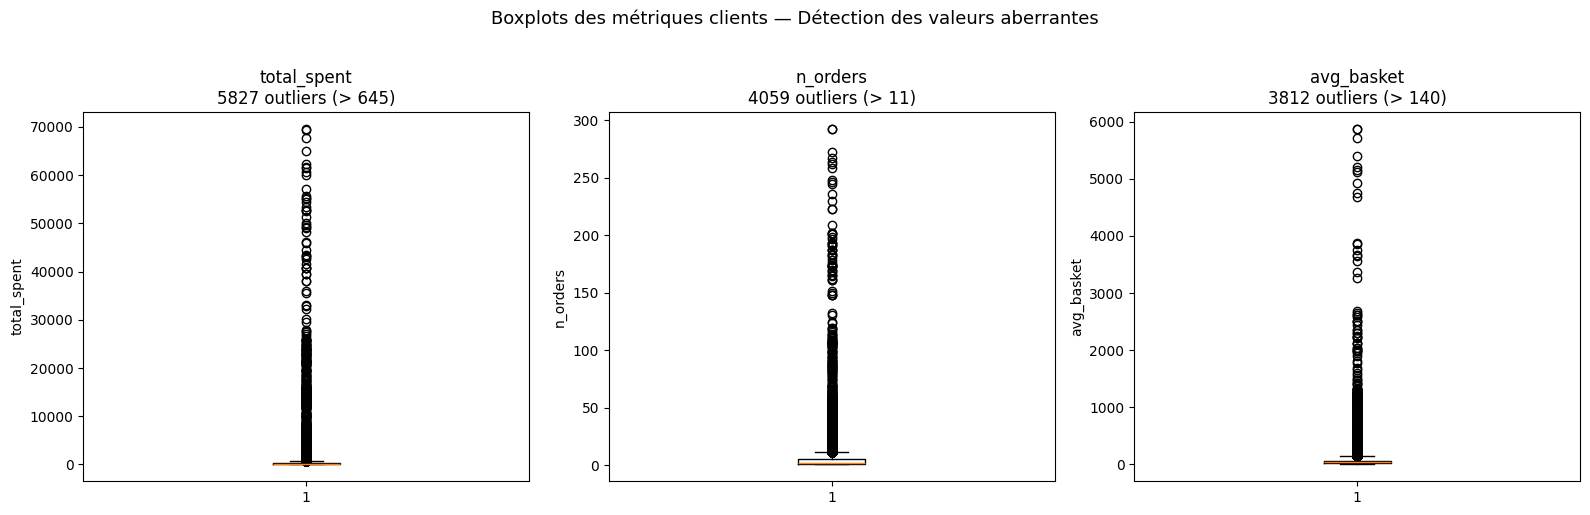


Clients avec n_orders < 1 (fractionnaires / bootstrapping) : 7,558
Exemple :
    customer_id  n_orders  total_spent  avg_basket
3         25889      0.98        24.53       25.15
6         24264      0.86        13.26       13.08
14        31913      0.98        43.05       47.79
21        29350      0.89        13.93       14.38
24        26908      0.92        33.29       32.56


In [64]:
# Détection des outliers avec la méthode IQR
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ['total_spent', 'n_orders', 'avg_basket']):
    q1 = customers[col].quantile(0.25)
    q3 = customers[col].quantile(0.75)
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    n_out = (customers[col] > upper).sum()
    
    ax.boxplot(customers[col], vert=True)
    ax.set_title(f"{col}\n{n_out} outliers (> {upper:.0f})")
    ax.set_ylabel(col)

plt.suptitle("Boxplots des métriques clients — Détection des valeurs aberrantes", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Clients avec n_orders < 1
print(f"\nClients avec n_orders < 1 (fractionnaires / bootstrapping) : {(customers['n_orders'] < 1).sum():,}")
print(f"Exemple :")
print(customers[customers['n_orders'] < 1][['customer_id', 'n_orders', 'total_spent', 'avg_basket']].head(5).to_string())

Pour les valeurs aberrantes sur le montant total dépensé, le nombre de commandes et le panier moyen, on a environ 8 à 12 pourcent d'outliers. Je décide de les garder, mais de bien les signaler. Dans le commerce, ces très gros acheteurs sont souvent de vrais clients. Si on les supprime, on passe à côté des fameux 20 pourcent de clients qui génèrent 80 pourcent du chiffre d'affaires. D'ailleurs, j'ai aussi remarqué des nombres de commandes avec des virgules, du style 0.85, mais c'est normal car ça vient du processus de rééchantillonnage de la base de données, donc je n'y touche pas non plus.

Clients one-shot (≈1 commande) : 17,477 (35.0%)
Clients récurrents (>1)         : 32,523 (65.0%)


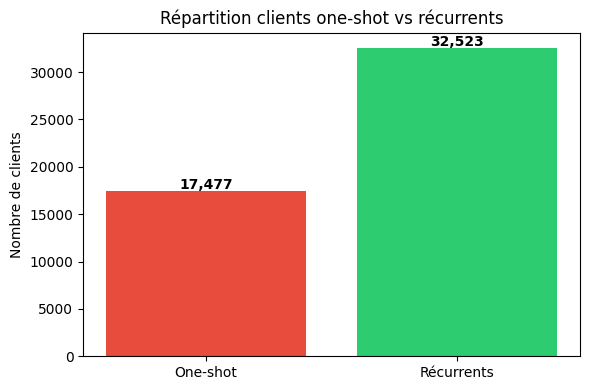

In [65]:
# Proportion clients one-shot vs récurrents
single = (customers['n_orders'].round() == 1).sum()
recurring = len(customers) - single

print(f"Clients one-shot (≈1 commande) : {single:,} ({100*single/len(customers):.1f}%)")
print(f"Clients récurrents (>1)         : {recurring:,} ({100*recurring/len(customers):.1f}%)")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['One-shot', 'Récurrents'], [single, recurring], color=['#e74c3c', '#2ecc71'])
ax.set_ylabel('Nombre de clients')
ax.set_title('Répartition clients one-shot vs récurrents')
for i, v in enumerate([single, recurring]):
    ax.text(i, v + 200, f"{v:,}", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

J'ai remarqué qu'environ 4,5 pourcent des clients, soit 2 235 personnes, n'ont fait qu'une seule commande. Je décide de les garder parce qu'un profil "one-shot", c'est super intéressant en marketing, surtout comme cible pour des campagnes de réactivation. Si on les enlève, notre segmentation sera complètement biaisée puisqu'on ne se focaliserait que sur les clients fidèles.

Recap :

In [66]:
# Bilan final des transactions nettoyées
print("=" * 60)
print("BILAN DU NETTOYAGE — transactions.csv")
print("=" * 60)
print(f"Lignes initiales         : 1,837,137")
print(f"Lignes après nettoyage   : {len(transactions):,}")
print(f"Lignes supprimées        : {1_837_137 - len(transactions):,} ({100*(1_837_137 - len(transactions))/1_837_137:.1f}%)")
print()
print("Colonnes :", list(transactions.columns))
print()
print("Nulls restants :")
print(transactions.isnull().sum())
print()
print("Statistiques descriptives :")
print(transactions.describe().round(2).to_string())
print()
print("=" * 60)
print("BILAN — customers.csv")
print("=" * 60)
print(f"Lignes : {len(customers):,} (aucune suppression)")
print("Aucune anomalie critique détectée.")
print("Outliers documentés mais conservés (business-relevant).")

BILAN DU NETTOYAGE — transactions.csv
Lignes initiales         : 1,837,137
Lignes après nettoyage   : 1,353,703
Lignes supprimées        : 483,434 (26.3%)

Colonnes : ['invoice_id', 'customer_id', 'product_code', 'product_name', 'quantity', 'unit_price', 'invoice_date', 'country', 'line_total']

Nulls restants :
invoice_id         0
customer_id        0
product_code       0
product_name    2367
quantity           0
unit_price         0
invoice_date       0
country            0
line_total         0
dtype: int64

Statistiques descriptives :
       customer_id    quantity  unit_price                invoice_date  line_total
count   1353703.00  1353703.00  1353703.00                     1353703  1353703.00
mean      22532.86       13.31        2.92  2010-11-28 18:41:17.691472       22.62
min       12346.00        1.00        0.00         2007-07-06 12:20:00        0.00
25%       14911.00        2.00        1.25         2010-06-03 10:28:00        4.35
50%       17558.00        5.00        1.